In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
from tqdm import tqdm
import numpy as np

In [5]:
train = pd.read_csv(f"train_pm10.csv")
test = pd.read_csv(f"test_pm10.csv")

feature_cols = [
        "hour", "month", "day", "weekday", "is_weekend",
        "lag1", "lag24", "rolling3", "rolling24",
    ]

X_train = train[feature_cols]
y_train = train["pm10"]

X_test = test[feature_cols]
y_test = test["pm10"]

In [6]:
train.iloc[0]

date           2024-01-01
측정망                    항만
측정소명          [강원 강릉시]옥계항
지점ID                  NaN
지점                    NaN
hour                    2
pm10                 24.0
station       [강원 강릉시]옥계항
month           -1.589802
day             -1.669345
weekday         -1.493752
is_weekend      -0.631996
lag1            -0.260484
lag24                 0.0
rolling3        -0.266861
rolling24       -0.308027
Name: 0, dtype: object

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0),
    "Lasso(alpha=0.1)": Lasso(alpha=0.1, max_iter=10000),
}

results = []

for name, model in tqdm(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        "model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
print(results_df)

100%|██████████| 3/3 [00:40<00:00, 13.37s/it]

              model        R2       MAE      RMSE
1  Ridge(alpha=1.0)  0.915073  2.568711  4.360437
0  LinearRegression  0.915073  2.568712  4.360437
2  Lasso(alpha=0.1)  0.907412  2.676190  4.552872


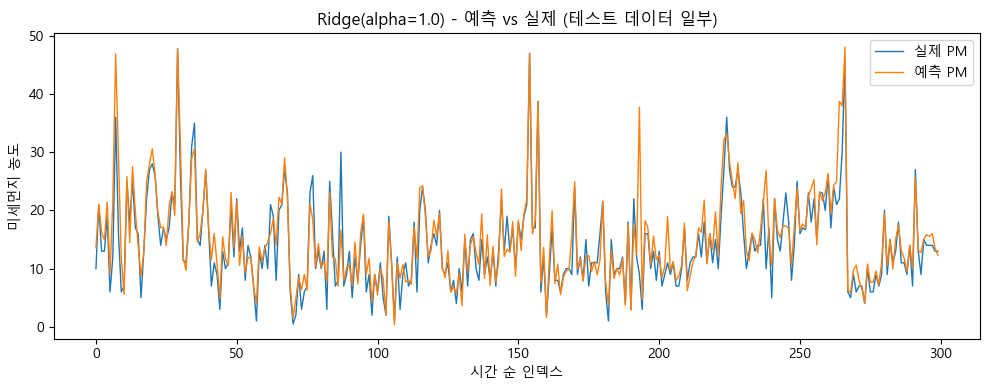

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 성능 좋은 모델로 예측값 생성
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

# test 데이터프레임에 예측값
test_with_pred = test.copy()
test_with_pred["y_true"] = y_test.values
test_with_pred["y_pred"] = y_pred_best

N = 300 
df_plot = test_with_pred.sort_values(["date", "hour"]).head(N)
font_path = './malgun.ttf'
font_name = plt.matplotlib.font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.figure(figsize=(10, 4))
plt.plot(df_plot["y_true"].values, label="실제 PM10", linewidth=1)
plt.plot(df_plot["y_pred"].values, label="예측 PM10", linewidth=1)
plt.title(f"{best_model_name} - 예측 vs 실제 (테스트 데이터 일부)")
plt.xlabel("시간 순 인덱스")
plt.ylabel("미세먼지 농도")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
def demo_predict_one(model, scaler, df_all, feature_cols, station, date_str, hour, pm):
    row = df_all[
        (df_all["station"] == station) &
        (df_all["date"] == date_str) &
        (df_all["hour"] == hour)
    ]

    if len(row) == 0:
        print("해당 station/date/hour 데이터가 없습니다.")
        return

    X_row = row[feature_cols]
    y_true = row[pm].values[0]

    y_pred = model.predict(X_row)[0]

    print(f"*** 예측 ***")
    print(f"측정소     : {station}")
    print(f"날짜/시간  : {date_str} {hour}시")
    print(f"실제 PM10  : {y_true:.2f}")
    print(f"예측 PM10  : {y_pred:.2f}")
    print(f"오차(예측-실제) : {y_pred - y_true:.2f}")


In [78]:
import joblib
pm_list = ["pm10", "pm2.5"]
df_model = pd.read_csv(f"preprocessed_{pm_list[0]}.csv")
scaler = joblib.load(f"scaler_{pm_list[0]}.pkl")
feature_cols = [
        "hour", "month", "day", "weekday", "is_weekend",
        "lag1", "lag24", "rolling3", "rolling24",
    ]

X_train = train[feature_cols]
y_train = train[pm_list[0]]

X_test = test[feature_cols]
y_test = test[pm_list[0]]

In [65]:
demo_predict_one(
    model=best_model,
    scaler=scaler,
    df_all=df_model,
    feature_cols=feature_cols,
    station="[대전 서구]둔산동",  
    date_str="2025-09-23",
    hour=12
)

=== 실증 예측 데모 ===
측정소     : [대전 서구]둔산동
날짜/시간  : 2025-09-23 12시
실제 PM10  : 6.00
예측 PM10  : 8.83
오차(예측-실제) : 2.83


In [ ]:
scaled_features = [
    "month", "day", "weekday", "is_weekend",
    "lag1", "lag24", "rolling3", "rolling24",
]

# hour는 스케일 안 된 원본 그대로, 나머지는 스케일된 값
feature_cols = ["hour"] + scaled_features

station_eval = []

target_stations = ["[대전 서구]월평동", "[대전 서구]둔산동",
                   "[충북 청주시]오창읍", "[충북 청주시]봉명동"]

for station in target_stations:
    subset = df_model[df_model["station"] == station]

    if subset.empty:
        print(f"{station} 데이터가 없습니다.")
        continue

    Xs = subset[feature_cols]
    ys = subset[pm_list[0]].values

    row = {"station": station}

    for name, model in models.items():
        pred = model.predict(Xs)
        rmse = np.sqrt(mean_squared_error(ys, pred))
        row[f"{name}(RMSE)"] = rmse

    station_eval.append(row)

station_eval_df = pd.DataFrame(station_eval)
station_eval_df

,station,LinearRegression(RMSE),Ridge(alpha=1.0)(RMSE),Lasso(alpha=0.1)(RMSE)
0,[대전 서구]월평동,5.048329,5.048330,5.196951
1,[대전 서구]둔산동,6.206140,6.206139,6.481529
2,[충북 청주시]오창읍,5.132852,5.132852,5.307994
3,[충북 청주시]봉명동,4.946626,4.946627,5.111690


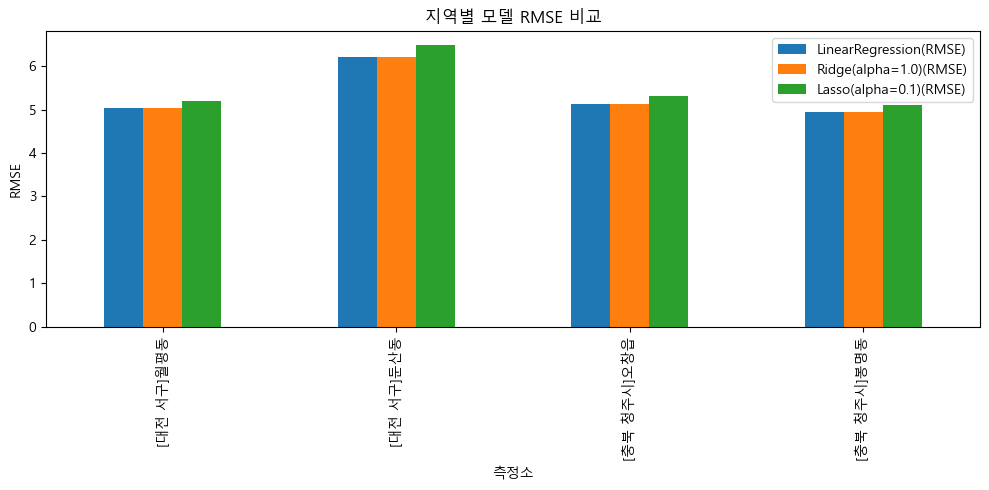

In [76]:
station_eval_df.set_index("station")[["LinearRegression(RMSE)", "Ridge(alpha=1.0)(RMSE)", "Lasso(alpha=0.1)(RMSE)"]].plot(kind="bar", figsize=(10,5))
font_path = './malgun.ttf'
font_name = plt.matplotlib.font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.title("지역별 모델 RMSE 비교")
plt.ylabel("RMSE")
plt.xlabel("측정소")
plt.tight_layout()
plt.show()

In [77]:
station = "[대전 서구]둔산동"
subset = df_model[df_model["station"] == station].sort_values(["date","hour"])

Xs = subset[feature_cols]
ys = subset[pm_list[0]].values
for name, model in models.items():
    pred = model.predict(Xs)

    plt.figure(figsize=(12,4))
    plt.plot(ys[:200], label="실제(관측)")
    plt.plot(pred[:200], label=f"예측({name})")
    plt.title(f"{station} - 실제 vs 예측 (상위 200시간) - {pm_list[0]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

NameError: name 'pm_list' is not defined